# **Tiền xử lí**

**Import**

In [ ]:
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
import seaborn as sns
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
from bs4 import BeautifulSoup
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk

# Nếu lần đầu sử dụng stopwords, cần tải dữ liệu:
nltk.download('stopwords')
nltk.download('punkt')

# Hàm clean dữ liệu
def clean_text(text):
    text = BeautifulSoup(text, "lxml").get_text()  # loại bỏ html
    text = re.sub(r'http\S+', '', text)  # loại bỏ url
    text = text.lower()  # chuyển về chữ thường
    text = re.sub(r'\d+', '', text)  # loại bỏ số
    text = re.sub(r'[^\w\s]', '', text)  # loại bỏ dấu câu
    text = re.sub(r'\s+', ' ', text).strip()  # loại bỏ khoảng trắng thừa
    return text

# Hàm tokenize
def tokenize_text(text):
    tokens = word_tokenize(text)
    return tokens

# Hàm loại bỏ stopwords
def remove_stopwords(tokens):
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return filtered_tokens

# Hàm xử lý văn bản hoàn chỉnh
def process_text(text):
    text = clean_text(text)
    tokens = tokenize_text(text)
    return tokens

# Hàm xử lý và trả về chuỗi văn bản đã làm sạch
def process_text_str(text):
    tokens = process_text(text)
    return ' '.join(tokens)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
import pandas as pd

# Đọc file data.csv
df = pd.read_csv('data.csv')

# Xóa các dòng có giá trị NaN
df = df.dropna()

# Tạo cột 'Comments_clean' sau khi xử lý cột 'Comments'
df['Comment_raw'] = df['Comment_raw'].apply(process_text_str)

# Xóa các dòng bị trùng dựa trên cột 'Comments' và 'Comments_clean'
df = df.drop_duplicates(subset=['Comment_raw'], keep='first')

print(df.head())
print(df.describe())

                                         Comment_raw Sentiment
0              uôi mv chất thế nhưng ló là chất thải       Neg
1  viruss chia tay tập trung cho sự nghiệp pháo s...       Neg
2  còn tên anh gây hại cho tổ quốc và nước nhà ba...       Pos
3                        eeegh is like a death sound       Neg
4  em nào nhân viên em nào đối tác con lợn này ch...       Pos
                                Comment_raw Sentiment
count                                  6707      6707
unique                                 6707         3
top     nhạc này làm con mình khóc quá trời       Pos
freq                                      1      2777


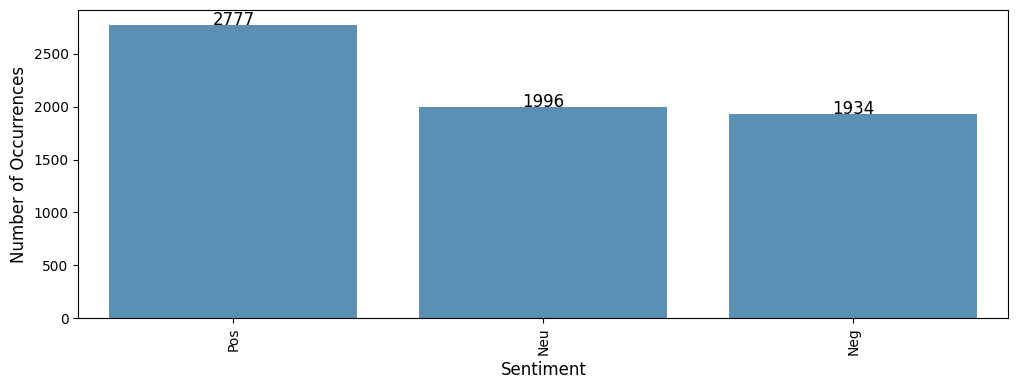

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cnt_pro = df['Sentiment'].value_counts()

plt.figure(figsize=(12, 4))
ax = sns.barplot(x=cnt_pro.index, y=cnt_pro.values, alpha=0.8)
plt.ylabel('Number of Occurrences', fontsize=12)
plt.xlabel('Sentiment', fontsize=12)
plt.xticks(rotation=90)

# Ghi số lên trên từng cột
for i, v in enumerate(cnt_pro.values):
    ax.text(i, v + 0.5, str(v), color='black', ha='center', fontsize=12)

plt.show()

# **Áp dụng BoW**

# **Binary**

- Mỗi từ trong từ điển (vocabulary) được gán một giá trị nhị phân:

    1: nếu từ đó xuất hiện trong tài liệu

    0: nếu từ đó không xuất hiện

- Chỉ quan tâm đến việc có hay không xuất hiện của từ, không quan tâm đến số lần xuất hiện.

- Giả sử từ điển gồm các từ: ["máy", "tính", "xách", "tay"].

    + VD1: văn bản: "máy tính xách tay" -> Vector: [1, 1, 1, 1]

    + VD2: văn bản là: "máy tính" -> Vector: [1, 1, 0, 0]

**Training**

In [ ]:
vectorizer_bi = CountVectorizer(binary=True)
X = vectorizer_bi.fit_transform(df['Comment_raw'])
y = df['Sentiment']

# Chia dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------------
# Mô hình Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
print("Naive Bayes accuracy:", accuracy_score(y_test, y_pred_nb))
print("Classification Report (Naive Bayes):")
print(classification_report(y_test, y_pred_nb))
print("===========================================================")

# -----------------------------
# Mô hình Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
print("Logistic Regression accuracy:", accuracy_score(y_test, y_pred_lr))
print("Classification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr))
print("===========================================================")

# -----------------------------
# Mô hình K-Nearest Neighbors (K-NN)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
print("K-Nearest Neighbors accuracy:", accuracy_score(y_test, y_pred_knn))
print("Classification Report (K-NN):")
print(classification_report(y_test, y_pred_knn))
print("===========================================================")

# -----------------------------
# Mô hình Decision Tree
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification Report (Decision Tree):")
print(classification_report(y_test, y_pred_dt))
print("===========================================================")

# -----------------------------
# Mô hình Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))
print("===========================================================")


Naive Bayes accuracy: 0.5991058122205664
Classification Report (Naive Bayes):
              precision    recall  f1-score   support

         Neg       0.72      0.51      0.60       404
         Neu       0.50      0.60      0.55       411
         Pos       0.62      0.66      0.64       527

    accuracy                           0.60      1342
   macro avg       0.62      0.59      0.60      1342
weighted avg       0.62      0.60      0.60      1342

Logistic Regression accuracy: 0.6758569299552906
Classification Report (Logistic Regression):
              precision    recall  f1-score   support

         Neg       0.67      0.63      0.65       404
         Neu       0.66      0.63      0.65       411
         Pos       0.69      0.75      0.72       527

    accuracy                           0.68      1342
   macro avg       0.67      0.67      0.67      1342
weighted avg       0.68      0.68      0.67      1342

K-Nearest Neighbors accuracy: 0.49254843517138597
Classification R

**Biểu đồ cột**

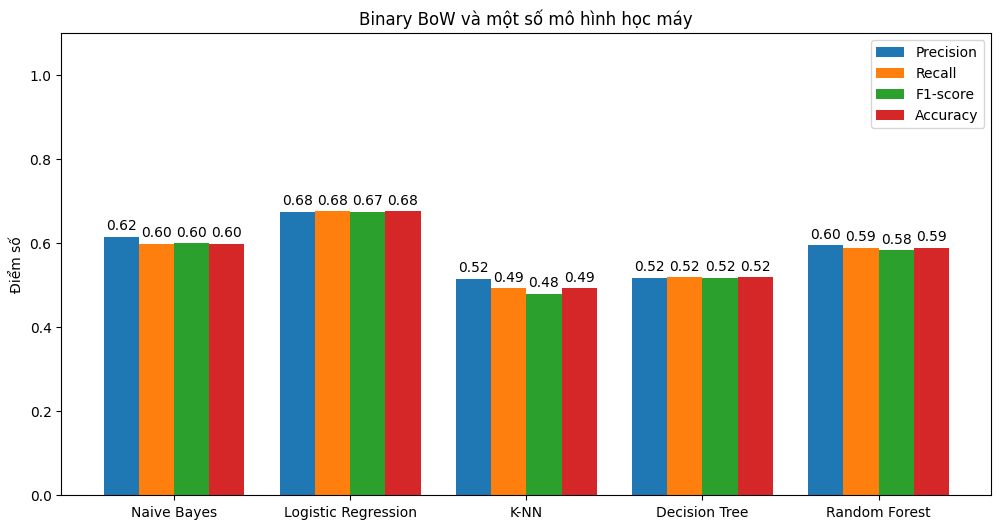

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score

# Tính báo cáo phân loại và lưu dưới dạng dictionary
nb_report = classification_report(y_test, y_pred_nb, output_dict=True)
lr_report = classification_report(y_test, y_pred_lr, output_dict=True)
knn_report = classification_report(y_test, y_pred_knn, output_dict=True)
dt_report = classification_report(y_test, y_pred_dt, output_dict=True)
rf_report = classification_report(y_test, y_pred_rf, output_dict=True)

# Tính accuracy cho từng mô hình
nb_accuracy = accuracy_score(y_test, y_pred_nb)
lr_accuracy = accuracy_score(y_test, y_pred_lr)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
dt_accuracy = accuracy_score(y_test, y_pred_dt)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

# Danh sách tên các phương pháp học máy
methods = ['Naive Bayes', 'Logistic Regression', "K-NN", 'Decision Tree', "Random Forest"]

# Lấy các chỉ số từ báo cáo phân loại dựa trên weighted avg
precision = [
    nb_report['weighted avg']['precision'],
    lr_report['weighted avg']['precision'],
    knn_report['weighted avg']['precision'],
    dt_report['weighted avg']['precision'],
    rf_report['weighted avg']['precision']
]
recall = [
    nb_report['weighted avg']['recall'],
    lr_report['weighted avg']['recall'],
    knn_report['weighted avg']['recall'],
    dt_report['weighted avg']['recall'],
    rf_report['weighted avg']['recall']
]
f1 = [
    nb_report['weighted avg']['f1-score'],
    lr_report['weighted avg']['f1-score'],
    knn_report['weighted avg']['f1-score'],
    dt_report['weighted avg']['f1-score'],
    rf_report['weighted avg']['f1-score']
]
accuracy = [nb_accuracy, lr_accuracy, knn_accuracy, dt_accuracy, rf_accuracy]

# Chuẩn bị vẽ biểu đồ: trục x là các phương pháp học máy
x = np.arange(len(methods))
width = 0.2  # Độ rộng của mỗi cột
# Các vị trí offset để căn chỉnh 4 cột đối xứng quanh mỗi nhóm
offsets = [-1.5 * width, -0.5 * width, 0.5 * width, 1.5 * width]

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x + offsets[0], precision, width, label='Precision')
rects2 = ax.bar(x + offsets[1], recall, width, label='Recall')
rects3 = ax.bar(x + offsets[2], f1, width, label='F1-score')
rects4 = ax.bar(x + offsets[3], accuracy, width, label='Accuracy')

# Hàm gắn số liệu (với định dạng 2 chữ số thập phân) lên trên mỗi cột
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3),  # cách trên 3 điểm
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1, ax)
autolabel(rects2, ax)
autolabel(rects3, ax)
autolabel(rects4, ax)

# Thiết lập nhãn, tiêu đề, trục x và legend
ax.set_ylabel('Điểm số')
ax.set_title('Binary BoW và một số mô hình học máy')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()

ax.set_ylim(0, 1.1)  # Giới hạn trục y từ 0 đến 1.05 để có khoảng trống cho số liệu

plt.show()

**Confusion Matrix**

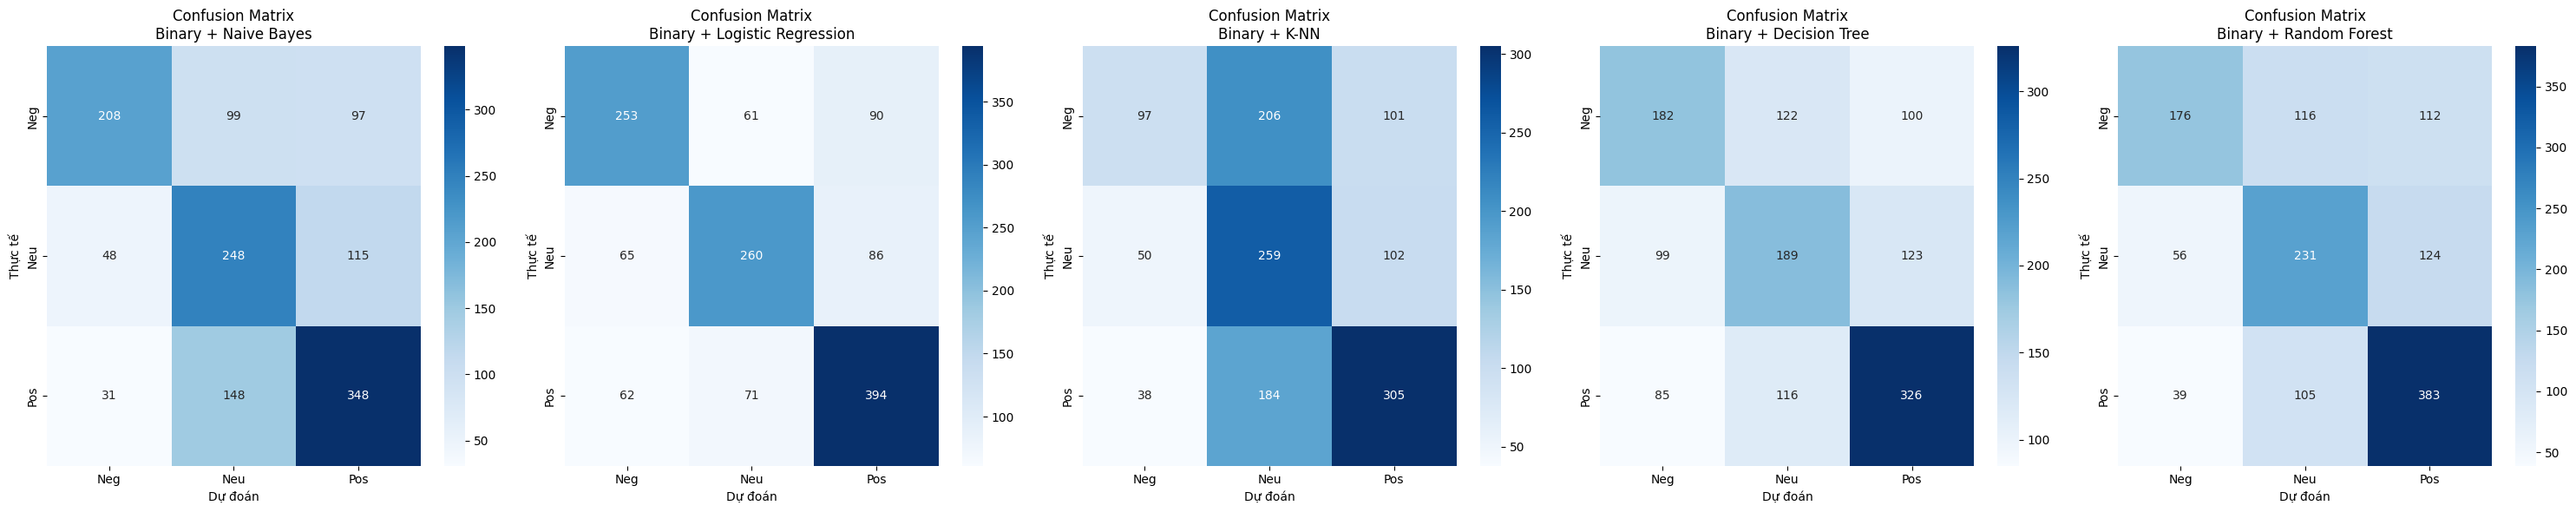

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Tạo figure với 5 subplots trên một hàng
fig, axs = plt.subplots(1, 5, figsize=(30, 6))

# --------------------
# Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues",
            xticklabels=nb_model.classes_,
            yticklabels=nb_model.classes_,
            ax=axs[0])
axs[0].set_xlabel("Dự đoán")
axs[0].set_ylabel("Thực tế")
axs[0].set_title("Confusion Matrix\nBinary + Naive Bayes")

# --------------------
# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=lr_model.classes_,
            yticklabels=lr_model.classes_,
            ax=axs[1])
axs[1].set_xlabel("Dự đoán")
axs[1].set_ylabel("Thực tế")
axs[1].set_title("Confusion Matrix\nBinary + Logistic Regression")

# --------------------
# K-NN
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues",
            xticklabels=knn_model.classes_,
            yticklabels=knn_model.classes_,
            ax=axs[2])
axs[2].set_xlabel("Dự đoán")
axs[2].set_ylabel("Thực tế")
axs[2].set_title("Confusion Matrix\nBinary + K-NN")

# --------------------
# Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues",
            xticklabels=dt_model.classes_,
            yticklabels=dt_model.classes_,
            ax=axs[3])
axs[3].set_xlabel("Dự đoán")
axs[3].set_ylabel("Thực tế")
axs[3].set_title("Confusion Matrix\nBinary + Decision Tree")

# --------------------
# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_,
            ax=axs[4])
axs[4].set_xlabel("Dự đoán")
axs[4].set_ylabel("Thực tế")
axs[4].set_title("Confusion Matrix\nBinary + Random Forest")

plt.tight_layout()
plt.show()


**Test**

In [ ]:
print("Binary")

# Danh sách các comment cần dự đoán
comments = [
    "Bày này bánh cuốn quá",
    "2025 Ai còn xem không",
    "Thấy cũng ok mà nhiều người chê vậy",
    "Tệ vậy mà cũng có nghe khen? chán thật",
    "Why this song become popular? it's trash at all!!"
]

# Duyệt qua từng comment
for comment in comments:
    # Tiền xử lý văn bản
    comment_clean = process_text_str(comment)
    print("\nComment gốc:", comment)
    print("Comment sau khi tiền xử lý:", comment_clean)

    # Chuyển đổi comment sang vector
    X_new = vectorizer_bi.transform([comment_clean])

    # -----------------------
    # Dự đoán với mô hình Naive Bayes
    probs_nb = nb_model.predict_proba(X_new)[0]
    print("Dự đoán cảm xúc (Naive Bayes):")
    for sentiment, prob in zip(nb_model.classes_, probs_nb):
        print(f"  {sentiment}: {prob*100:.2f}%")

    # -----------------------
    # Dự đoán với mô hình Logistic Regression
    probs_lr = lr_model.predict_proba(X_new)[0]
    print("Dự đoán cảm xúc (Logistic Regression):")
    for sentiment, prob in zip(lr_model.classes_, probs_lr):
        print(f"  {sentiment}: {prob*100:.2f}%")

    # -----------------------
    # Dự đoán với mô hình K-Nearest Neighbors (K-NN)
    probs_knn = knn_model.predict_proba(X_new)[0]
    print("Dự đoán cảm xúc K-Nearest Neighbors (K-NN):")
    for sentiment, prob in zip(knn_model.classes_, probs_knn):
        print(f"  {sentiment}: {prob*100:.2f}%")

    # -----------------------
    # Dự đoán với mô hình Decision Tree
    probs_dt = dt_model.predict_proba(X_new)[0]
    print("Dự đoán cảm xúc (Decision Tree):")
    for sentiment, prob in zip(dt_model.classes_, probs_dt):
        print(f"  {sentiment}: {prob*100:.2f}%")

    # -----------------------
    # Dự đoán với mô hình Random Forest
    probs_rf = rf_model.predict_proba(X_new)[0]
    print("Dự đoán cảm xúc (Random Forest):")
    for sentiment, prob in zip(rf_model.classes_, probs_rf):
        print(f"  {sentiment}: {prob*100:.2f}%")
    print("===========================================================")


Binary

Comment gốc: Bày này bánh cuốn quá
Comment sau khi tiền xử lý: bày này bánh cuốn quá
Dự đoán cảm xúc (Naive Bayes):
  Neg: 2.91%
  Neu: 0.62%
  Pos: 96.47%
Dự đoán cảm xúc (Logistic Regression):
  Neg: 4.99%
  Neu: 4.06%
  Pos: 90.94%
Dự đoán cảm xúc K-Nearest Neighbors (K-NN):
  Neg: 0.00%
  Neu: 0.00%
  Pos: 100.00%
Dự đoán cảm xúc (Decision Tree):
  Neg: 0.00%
  Neu: 0.00%
  Pos: 100.00%
Dự đoán cảm xúc (Random Forest):
  Neg: 18.00%
  Neu: 3.00%
  Pos: 79.00%

Comment gốc: 2025 Ai còn xem không
Comment sau khi tiền xử lý: ai còn xem không
Dự đoán cảm xúc (Naive Bayes):
  Neg: 6.11%
  Neu: 10.24%
  Pos: 83.64%
Dự đoán cảm xúc (Logistic Regression):
  Neg: 4.58%
  Neu: 18.75%
  Pos: 76.67%
Dự đoán cảm xúc K-Nearest Neighbors (K-NN):
  Neg: 0.00%
  Neu: 20.00%
  Pos: 80.00%
Dự đoán cảm xúc (Decision Tree):
  Neg: 0.00%
  Neu: 0.00%
  Pos: 100.00%
Dự đoán cảm xúc (Random Forest):
  Neg: 0.00%
  Neu: 2.63%
  Pos: 97.37%

Comment gốc: Thấy cũng ok mà nhiều người chê vậy
Comment s

# **Counting**

- Đếm số lần xuất hiện của từng từ trong tài liệu.

- Giả sử từ điển: ["máy", "tính", "xách", "tay"]

    + Văn bản: "máy tính, máy tính, xách tay"

        "máy": xuất hiện 2 lần

        "tính": xuất hiện 2 lần

        "xách": xuất hiện 1 lần

        "tay": xuất hiện 1 lần

            → Vector: [2, 2, 1, 1]

**Training**

In [ ]:
vectorizer_count = CountVectorizer()
X = vectorizer_count.fit_transform(df['Comment_raw'])
y = df['Sentiment']

# Chia dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------------
# Mô hình Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
print("Naive Bayes accuracy:", accuracy_score(y_test, y_pred_nb))
print("Classification Report (Naive Bayes):")
print(classification_report(y_test, y_pred_nb))
print("===========================================================")

# -----------------------------
# Mô hình Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
print("Logistic Regression accuracy:", accuracy_score(y_test, y_pred_lr))
print("Classification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr))
print("===========================================================")

# -----------------------------
# Mô hình K-Nearest Neighbors (K-NN)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
print("K-Nearest Neighbors accuracy:", accuracy_score(y_test, y_pred_knn))
print("Classification Report (K-NN):")
print(classification_report(y_test, y_pred_knn))
print("===========================================================")

# -----------------------------
# Mô hình Decision Tree
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification Report (Decision Tree):")
print(classification_report(y_test, y_pred_dt))

# -----------------------------
# Mô hình Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))
print("===========================================================")


Naive Bayes accuracy: 0.6005961251862891
Classification Report (Naive Bayes):
              precision    recall  f1-score   support

         Neg       0.71      0.52      0.60       404
         Neu       0.50      0.61      0.55       411
         Pos       0.63      0.66      0.65       527

    accuracy                           0.60      1342
   macro avg       0.62      0.59      0.60      1342
weighted avg       0.62      0.60      0.60      1342

Logistic Regression accuracy: 0.6818181818181818
Classification Report (Logistic Regression):
              precision    recall  f1-score   support

         Neg       0.68      0.63      0.65       404
         Neu       0.67      0.64      0.66       411
         Pos       0.69      0.75      0.72       527

    accuracy                           0.68      1342
   macro avg       0.68      0.67      0.68      1342
weighted avg       0.68      0.68      0.68      1342

K-Nearest Neighbors accuracy: 0.4918032786885246
Classification Re

**Biểu đồ cột**

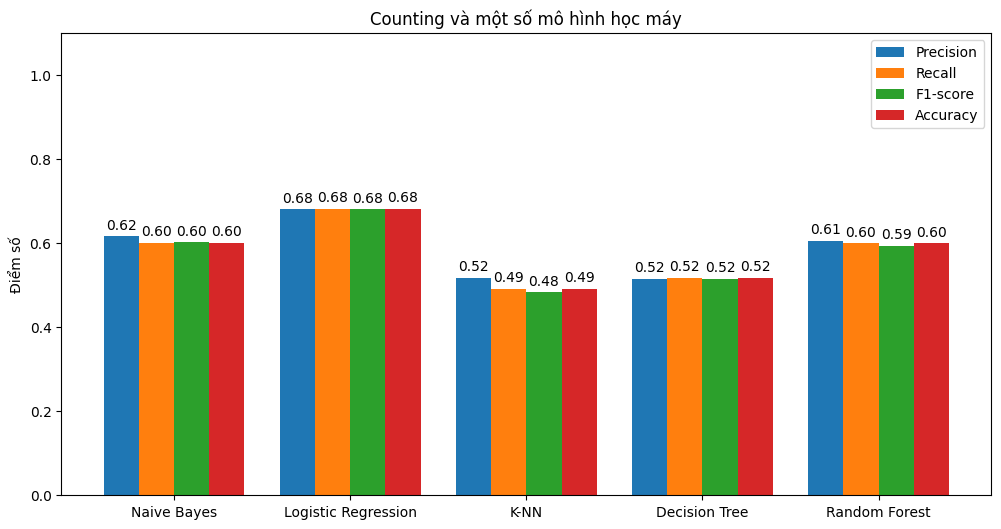

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score

# Tính báo cáo phân loại và lưu dưới dạng dictionary
nb_report = classification_report(y_test, y_pred_nb, output_dict=True)
lr_report = classification_report(y_test, y_pred_lr, output_dict=True)
knn_report = classification_report(y_test, y_pred_knn, output_dict=True)
dt_report = classification_report(y_test, y_pred_dt, output_dict=True)
rf_report = classification_report(y_test, y_pred_rf, output_dict=True)

# Tính accuracy cho từng mô hình
nb_accuracy = accuracy_score(y_test, y_pred_nb)
lr_accuracy = accuracy_score(y_test, y_pred_lr)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
dt_accuracy = accuracy_score(y_test, y_pred_dt)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

# Danh sách tên các phương pháp học máy
methods = ['Naive Bayes', 'Logistic Regression', "K-NN", 'Decision Tree', "Random Forest"]

# Lấy các chỉ số từ báo cáo phân loại dựa trên weighted avg
precision = [
    nb_report['weighted avg']['precision'],
    lr_report['weighted avg']['precision'],
    knn_report['weighted avg']['precision'],
    dt_report['weighted avg']['precision'],
    rf_report['weighted avg']['precision']
]
recall = [
    nb_report['weighted avg']['recall'],
    lr_report['weighted avg']['recall'],
    knn_report['weighted avg']['recall'],
    dt_report['weighted avg']['recall'],
    rf_report['weighted avg']['recall']
]
f1 = [
    nb_report['weighted avg']['f1-score'],
    lr_report['weighted avg']['f1-score'],
    knn_report['weighted avg']['f1-score'],
    dt_report['weighted avg']['f1-score'],
    rf_report['weighted avg']['f1-score']
]
accuracy = [nb_accuracy, lr_accuracy, knn_accuracy, dt_accuracy, rf_accuracy]

# Chuẩn bị vẽ biểu đồ: trục x là các phương pháp học máy
x = np.arange(len(methods))
width = 0.2  # Độ rộng của mỗi cột
# Các vị trí offset để căn chỉnh 4 cột đối xứng quanh mỗi nhóm
offsets = [-1.5 * width, -0.5 * width, 0.5 * width, 1.5 * width]

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x + offsets[0], precision, width, label='Precision')
rects2 = ax.bar(x + offsets[1], recall, width, label='Recall')
rects3 = ax.bar(x + offsets[2], f1, width, label='F1-score')
rects4 = ax.bar(x + offsets[3], accuracy, width, label='Accuracy')

# Hàm gắn số liệu (với định dạng 2 chữ số thập phân) lên trên mỗi cột
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3),  # cách trên 3 điểm
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1, ax)
autolabel(rects2, ax)
autolabel(rects3, ax)
autolabel(rects4, ax)

# Thiết lập nhãn, tiêu đề, trục x và legend
ax.set_ylabel('Điểm số')
ax.set_title('Counting và một số mô hình học máy')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()

ax.set_ylim(0, 1.1)  # Giới hạn trục y từ 0 đến 1.05 để có khoảng trống cho số liệu

plt.show()

**Confusion Matrix**

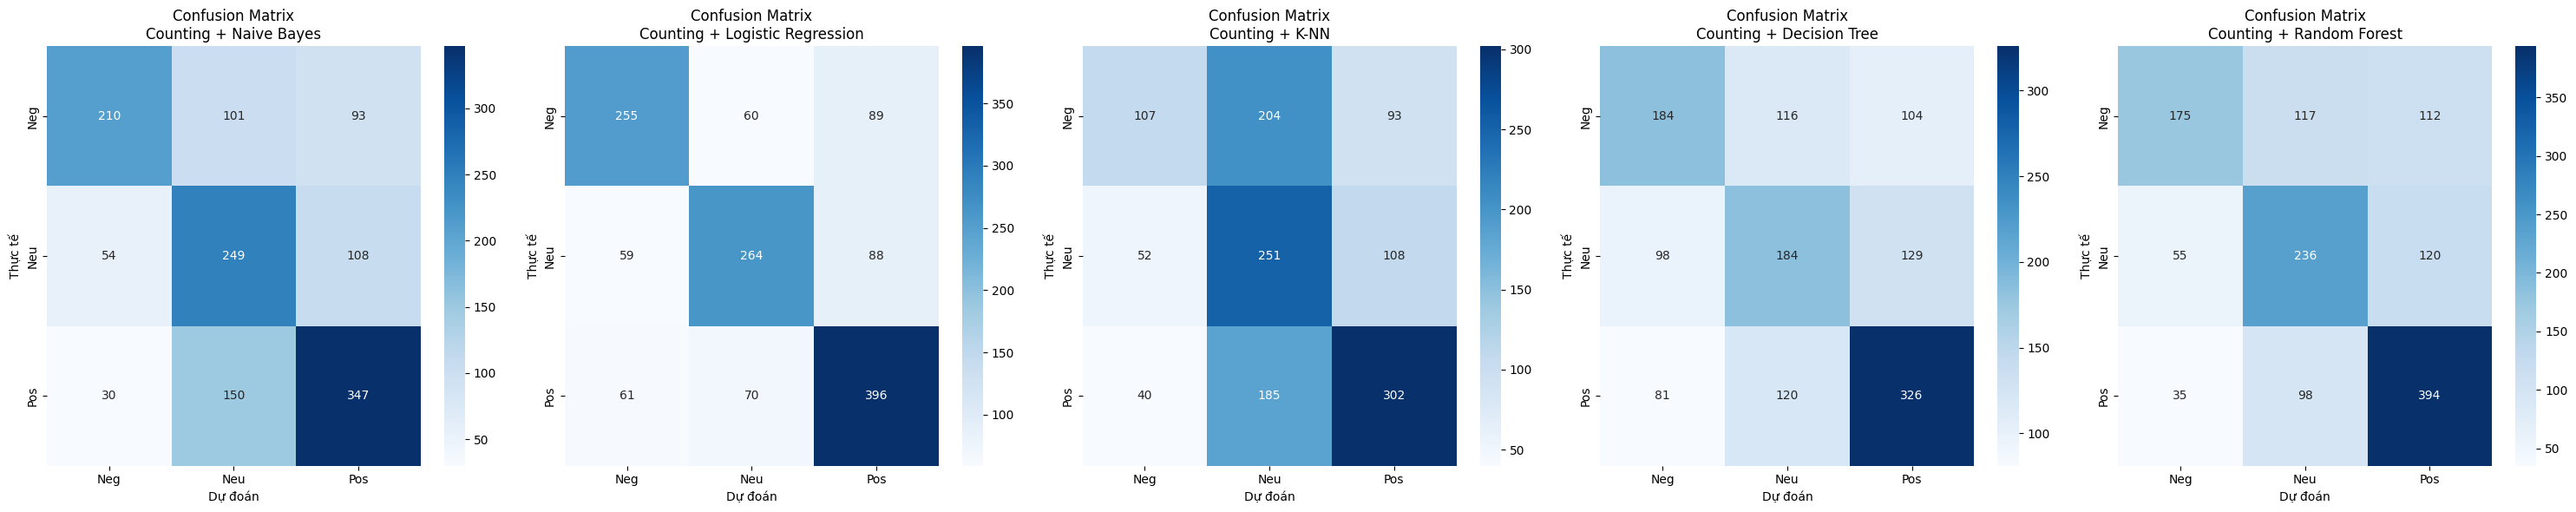

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Tạo figure với 5 subplots trên một hàng
fig, axs = plt.subplots(1, 5, figsize=(30, 6))

# --------------------
# Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues",
            xticklabels=nb_model.classes_,
            yticklabels=nb_model.classes_,
            ax=axs[0])
axs[0].set_xlabel("Dự đoán")
axs[0].set_ylabel("Thực tế")
axs[0].set_title("Confusion Matrix\nCounting + Naive Bayes")

# --------------------
# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=lr_model.classes_,
            yticklabels=lr_model.classes_,
            ax=axs[1])
axs[1].set_xlabel("Dự đoán")
axs[1].set_ylabel("Thực tế")
axs[1].set_title("Confusion Matrix\nCounting + Logistic Regression")

# --------------------
# K-NN
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues",
            xticklabels=knn_model.classes_,
            yticklabels=knn_model.classes_,
            ax=axs[2])
axs[2].set_xlabel("Dự đoán")
axs[2].set_ylabel("Thực tế")
axs[2].set_title("Confusion Matrix\nCounting + K-NN")

# --------------------
# Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues",
            xticklabels=dt_model.classes_,
            yticklabels=dt_model.classes_,
            ax=axs[3])
axs[3].set_xlabel("Dự đoán")
axs[3].set_ylabel("Thực tế")
axs[3].set_title("Confusion Matrix\nCounting + Decision Tree")

# --------------------
# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_,
            ax=axs[4])
axs[4].set_xlabel("Dự đoán")
axs[4].set_ylabel("Thực tế")
axs[4].set_title("Confusion Matrix\nCounting + Random Forest")

plt.tight_layout()
plt.show()


**Test**

In [ ]:
print("Counting")

# Danh sách các comment cần dự đoán
comments = [
    "Bày này bánh cuốn quá",
    "2025 Ai còn xem không",
    "Thấy cũng ok mà nhiều người chê vậy",
    "Tệ vậy mà cũng có nghe khen? chán thật",
    "Why this song become popular? it's trash at all!!"
]

# Duyệt qua từng comment
for comment in comments:
    # Tiền xử lý văn bản
    comment_clean = process_text_str(comment)
    print("\nComment gốc:", comment)
    print("Comment sau khi tiền xử lý:", comment_clean)

    # Chuyển đổi comment sang vector
    X_new = vectorizer_count.transform([comment_clean])

    # -----------------------
    # Dự đoán với mô hình Naive Bayes
    probs_nb = nb_model.predict_proba(X_new)[0]
    print("Dự đoán cảm xúc (Naive Bayes):")
    for sentiment, prob in zip(nb_model.classes_, probs_nb):
        print(f"  {sentiment}: {prob*100:.2f}%")

    # -----------------------
    # Dự đoán với mô hình Logistic Regression
    probs_lr = lr_model.predict_proba(X_new)[0]
    print("Dự đoán cảm xúc (Logistic Regression):")
    for sentiment, prob in zip(lr_model.classes_, probs_lr):
        print(f"  {sentiment}: {prob*100:.2f}%")

    # -----------------------
    # Dự đoán với mô hình K-Nearest Neighbors (K-NN)
    probs_knn = knn_model.predict_proba(X_new)[0]
    print("Dự đoán cảm xúc K-Nearest Neighbors (K-NN):")
    for sentiment, prob in zip(knn_model.classes_, probs_knn):
        print(f"  {sentiment}: {prob*100:.2f}%")

    # -----------------------
    # Dự đoán với mô hình Decision Tree
    probs_dt = dt_model.predict_proba(X_new)[0]
    print("Dự đoán cảm xúc (Decision Tree):")
    for sentiment, prob in zip(dt_model.classes_, probs_dt):
        print(f"  {sentiment}: {prob*100:.2f}%")

    # -----------------------
    # Dự đoán với mô hình Random Forest
    probs_rf = rf_model.predict_proba(X_new)[0]
    print("Dự đoán cảm xúc (Decision Tree):")
    for sentiment, prob in zip(rf_model.classes_, probs_rf):
        print(f"  {sentiment}: {prob*100:.2f}%")
    print("===========================================================")


Counting

Comment gốc: Bày này bánh cuốn quá
Comment sau khi tiền xử lý: bày này bánh cuốn quá
Dự đoán cảm xúc (Naive Bayes):
  Neg: 2.38%
  Neu: 0.57%
  Pos: 97.05%
Dự đoán cảm xúc (Logistic Regression):
  Neg: 4.08%
  Neu: 3.63%
  Pos: 92.29%
Dự đoán cảm xúc K-Nearest Neighbors (K-NN):
  Neg: 0.00%
  Neu: 20.00%
  Pos: 80.00%
Dự đoán cảm xúc (Decision Tree):
  Neg: 0.00%
  Neu: 0.00%
  Pos: 100.00%
Dự đoán cảm xúc (Decision Tree):
  Neg: 16.00%
  Neu: 2.00%
  Pos: 82.00%

Comment gốc: 2025 Ai còn xem không
Comment sau khi tiền xử lý: ai còn xem không
Dự đoán cảm xúc (Naive Bayes):
  Neg: 9.54%
  Neu: 9.63%
  Pos: 80.82%
Dự đoán cảm xúc (Logistic Regression):
  Neg: 5.43%
  Neu: 18.85%
  Pos: 75.72%
Dự đoán cảm xúc K-Nearest Neighbors (K-NN):
  Neg: 0.00%
  Neu: 0.00%
  Pos: 100.00%
Dự đoán cảm xúc (Decision Tree):
  Neg: 0.00%
  Neu: 0.00%
  Pos: 100.00%
Dự đoán cảm xúc (Decision Tree):
  Neg: 0.00%
  Neu: 1.80%
  Pos: 98.20%

Comment gốc: Thấy cũng ok mà nhiều người chê vậy
Comment 

# **N-gram**

- N-gram là tập hợp liên tiếp của N từ (ký tự) trong văn bản.

- Văn bản: "máy tính xách tay"

    + Unigram: xem từng từ riêng lẻ -> ["máy", "tính", "xách", "tay"]

    + Bigram: xem cặp từ liên tiếp -> ["máy tính", "tính xách", "xách tay"]

    + Trigram: xem nhóm 3 từ liên tiếp -> Trigram: ["máy tính xách", "tính xách tay"]

**Training**

In [ ]:
vectorizer_ngram = CountVectorizer(ngram_range=(1, 2))
X = vectorizer_ngram.fit_transform(df['Comment_raw'])
y = df['Sentiment']

# Chia dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------------
# Mô hình Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
print("Naive Bayes accuracy:", accuracy_score(y_test, y_pred_nb))
print("Classification Report (Naive Bayes):")
print(classification_report(y_test, y_pred_nb))
print("===========================================================")

# -----------------------------
# Mô hình Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
print("Logistic Regression accuracy:", accuracy_score(y_test, y_pred_lr))
print("Classification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr))
print("===========================================================")

# -----------------------------
# Mô hình K-Nearest Neighbors (K-NN)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

print("K-Nearest Neighbors accuracy:", accuracy_score(y_test, y_pred_knn))
print("Classification Report (K-NN):")
print(classification_report(y_test, y_pred_knn))
print("===========================================================")

# -----------------------------
# Mô hình Decision Tree
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification Report (Decision Tree):")
print(classification_report(y_test, y_pred_dt))
print("===========================================================")

# -----------------------------
# Mô hình Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))
print("===========================================================")


Naive Bayes accuracy: 0.6125186289120715
Classification Report (Naive Bayes):
              precision    recall  f1-score   support

         Neg       0.70      0.52      0.60       404
         Neu       0.53      0.60      0.56       411
         Pos       0.63      0.69      0.66       527

    accuracy                           0.61      1342
   macro avg       0.62      0.60      0.61      1342
weighted avg       0.62      0.61      0.61      1342

Logistic Regression accuracy: 0.6780923994038748
Classification Report (Logistic Regression):
              precision    recall  f1-score   support

         Neg       0.69      0.61      0.65       404
         Neu       0.65      0.63      0.64       411
         Pos       0.69      0.77      0.73       527

    accuracy                           0.68      1342
   macro avg       0.68      0.67      0.67      1342
weighted avg       0.68      0.68      0.68      1342

K-Nearest Neighbors accuracy: 0.4187779433681073
Classification Re

**Biểu đồ cột**

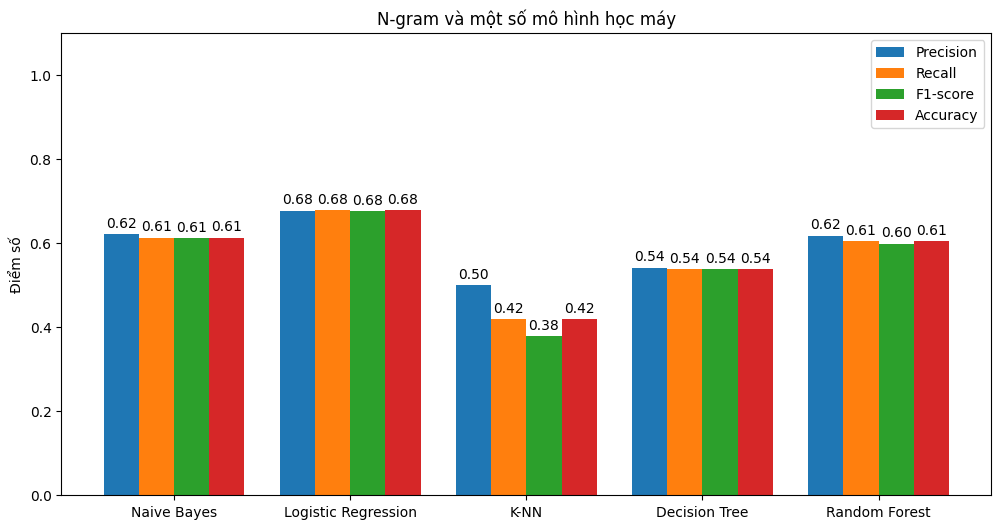

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score

# Tính báo cáo phân loại và lưu dưới dạng dictionary
nb_report = classification_report(y_test, y_pred_nb, output_dict=True)
lr_report = classification_report(y_test, y_pred_lr, output_dict=True)
knn_report = classification_report(y_test, y_pred_knn, output_dict=True)
dt_report = classification_report(y_test, y_pred_dt, output_dict=True)
rf_report = classification_report(y_test, y_pred_rf, output_dict=True)

# Tính accuracy cho từng mô hình
nb_accuracy = accuracy_score(y_test, y_pred_nb)
lr_accuracy = accuracy_score(y_test, y_pred_lr)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
dt_accuracy = accuracy_score(y_test, y_pred_dt)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

# Danh sách tên các phương pháp học máy
methods = ['Naive Bayes', 'Logistic Regression', "K-NN", 'Decision Tree', "Random Forest"]

# Lấy các chỉ số từ báo cáo phân loại dựa trên weighted avg
precision = [
    nb_report['weighted avg']['precision'],
    lr_report['weighted avg']['precision'],
    knn_report['weighted avg']['precision'],
    dt_report['weighted avg']['precision'],
    rf_report['weighted avg']['precision']
]
recall = [
    nb_report['weighted avg']['recall'],
    lr_report['weighted avg']['recall'],
    knn_report['weighted avg']['recall'],
    dt_report['weighted avg']['recall'],
    rf_report['weighted avg']['recall']
]
f1 = [
    nb_report['weighted avg']['f1-score'],
    lr_report['weighted avg']['f1-score'],
    knn_report['weighted avg']['f1-score'],
    dt_report['weighted avg']['f1-score'],
    rf_report['weighted avg']['f1-score']
]
accuracy = [nb_accuracy, lr_accuracy, knn_accuracy, dt_accuracy, rf_accuracy]

# Chuẩn bị vẽ biểu đồ: trục x là các phương pháp học máy
x = np.arange(len(methods))
width = 0.2  # Độ rộng của mỗi cột
# Các vị trí offset để căn chỉnh 4 cột đối xứng quanh mỗi nhóm
offsets = [-1.5 * width, -0.5 * width, 0.5 * width, 1.5 * width]

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x + offsets[0], precision, width, label='Precision')
rects2 = ax.bar(x + offsets[1], recall, width, label='Recall')
rects3 = ax.bar(x + offsets[2], f1, width, label='F1-score')
rects4 = ax.bar(x + offsets[3], accuracy, width, label='Accuracy')

# Hàm gắn số liệu (với định dạng 2 chữ số thập phân) lên trên mỗi cột
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3),  # cách trên 3 điểm
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1, ax)
autolabel(rects2, ax)
autolabel(rects3, ax)
autolabel(rects4, ax)

# Thiết lập nhãn, tiêu đề, trục x và legend
ax.set_ylabel('Điểm số')
ax.set_title('N-gram và một số mô hình học máy')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()

ax.set_ylim(0, 1.1)  # Giới hạn trục y từ 0 đến 1.05 để có khoảng trống cho số liệu

plt.show()

**Confusion Matrix**

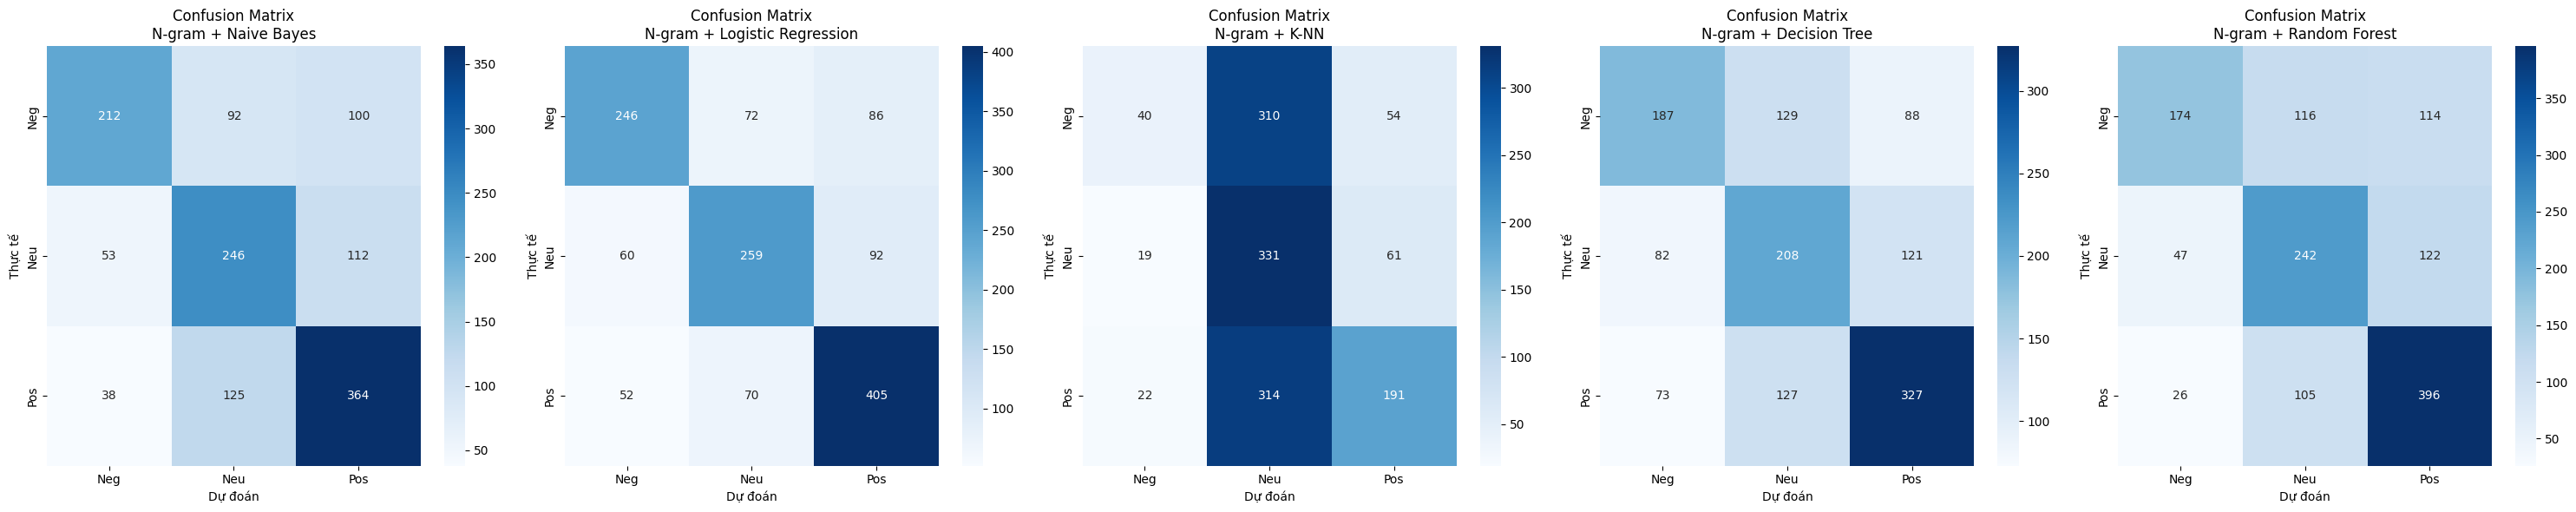

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Tạo figure với 5 subplots trên một hàng
fig, axs = plt.subplots(1, 5, figsize=(30, 6))

# --------------------
# Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues",
            xticklabels=nb_model.classes_,
            yticklabels=nb_model.classes_,
            ax=axs[0])
axs[0].set_xlabel("Dự đoán")
axs[0].set_ylabel("Thực tế")
axs[0].set_title("Confusion Matrix\nN-gram + Naive Bayes")

# --------------------
# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=lr_model.classes_,
            yticklabels=lr_model.classes_,
            ax=axs[1])
axs[1].set_xlabel("Dự đoán")
axs[1].set_ylabel("Thực tế")
axs[1].set_title("Confusion Matrix\nN-gram + Logistic Regression")

# --------------------
# K-NN
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues",
            xticklabels=knn_model.classes_,
            yticklabels=knn_model.classes_,
            ax=axs[2])
axs[2].set_xlabel("Dự đoán")
axs[2].set_ylabel("Thực tế")
axs[2].set_title("Confusion Matrix\nN-gram + K-NN")

# --------------------
# Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues",
            xticklabels=dt_model.classes_,
            yticklabels=dt_model.classes_,
            ax=axs[3])
axs[3].set_xlabel("Dự đoán")
axs[3].set_ylabel("Thực tế")
axs[3].set_title("Confusion Matrix\nN-gram + Decision Tree")

# --------------------
# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_,
            ax=axs[4])
axs[4].set_xlabel("Dự đoán")
axs[4].set_ylabel("Thực tế")
axs[4].set_title("Confusion Matrix\nN-gram + Random Forest")

plt.tight_layout()
plt.show()


**Test**

In [ ]:
print("N-gram")

# Danh sách các comment cần dự đoán
comments = [
    "Bày này bánh cuốn quá",
    "2025 Ai còn xem không",
    "Thấy cũng ok mà nhiều người chê vậy",
    "Tệ vậy mà cũng có nghe khen? chán thật",
    "Why this song become popular? it's trash at all!!"
]

# Duyệt qua từng comment
for comment in comments:
    # Tiền xử lý văn bản
    comment_clean = process_text_str(comment)
    print("\nComment gốc:", comment)
    print("Comment sau khi tiền xử lý:", comment_clean)

    # Chuyển đổi comment sang vector
    X_new = vectorizer_ngram.transform([comment_clean])

    # -----------------------
    # Dự đoán với mô hình Naive Bayes
    probs_nb = nb_model.predict_proba(X_new)[0]
    print("Dự đoán cảm xúc (Naive Bayes):")
    for sentiment, prob in zip(nb_model.classes_, probs_nb):
        print(f"  {sentiment}: {prob*100:.2f}%")

    # -----------------------
    # Dự đoán với mô hình Logistic Regression
    probs_lr = lr_model.predict_proba(X_new)[0]
    print("Dự đoán cảm xúc (Logistic Regression):")
    for sentiment, prob in zip(lr_model.classes_, probs_lr):
        print(f"  {sentiment}: {prob*100:.2f}%")

    # -----------------------
    # Dự đoán với mô hình K-Nearest Neighbors (K-NN)
    probs_knn = knn_model.predict_proba(X_new)[0]
    print("Dự đoán cảm xúc K-Nearest Neighbors (K-NN):")
    for sentiment, prob in zip(knn_model.classes_, probs_knn):
        print(f"  {sentiment}: {prob*100:.2f}%")

    # -----------------------
    # Dự đoán với mô hình Decision Tree
    probs_dt = dt_model.predict_proba(X_new)[0]
    print("Dự đoán cảm xúc (Decision Tree):")
    for sentiment, prob in zip(dt_model.classes_, probs_dt):
        print(f"  {sentiment}: {prob*100:.2f}%")

    # -----------------------
    # Dự đoán với mô hình Random Forest
    probs_rf = rf_model.predict_proba(X_new)[0]
    print("Dự đoán cảm xúc (Random Forest):")
    for sentiment, prob in zip(rf_model.classes_, probs_rf):
        print(f"  {sentiment}: {prob*100:.2f}%")
    print("===========================================================")


N-gram

Comment gốc: Bày này bánh cuốn quá
Comment sau khi tiền xử lý: bày này bánh cuốn quá
Dự đoán cảm xúc (Naive Bayes):
  Neg: 0.03%
  Neu: 0.03%
  Pos: 99.94%
Dự đoán cảm xúc (Logistic Regression):
  Neg: 2.71%
  Neu: 2.17%
  Pos: 95.12%
Dự đoán cảm xúc K-Nearest Neighbors (K-NN):
  Neg: 0.00%
  Neu: 60.00%
  Pos: 40.00%
Dự đoán cảm xúc (Decision Tree):
  Neg: 0.00%
  Neu: 0.00%
  Pos: 100.00%
Dự đoán cảm xúc (Random Forest):
  Neg: 12.00%
  Neu: 1.00%
  Pos: 87.00%

Comment gốc: 2025 Ai còn xem không
Comment sau khi tiền xử lý: ai còn xem không
Dự đoán cảm xúc (Naive Bayes):
  Neg: 0.01%
  Neu: 1.79%
  Pos: 98.20%
Dự đoán cảm xúc (Logistic Regression):
  Neg: 1.72%
  Neu: 18.86%
  Pos: 79.42%
Dự đoán cảm xúc K-Nearest Neighbors (K-NN):
  Neg: 0.00%
  Neu: 60.00%
  Pos: 40.00%
Dự đoán cảm xúc (Decision Tree):
  Neg: 0.00%
  Neu: 0.00%
  Pos: 100.00%
Dự đoán cảm xúc (Random Forest):
  Neg: 0.00%
  Neu: 17.00%
  Pos: 83.00%

Comment gốc: Thấy cũng ok mà nhiều người chê vậy
Comment s

# **Hashing**

- Sử dụng hàm băm để chuyển mỗi từ thành một chỉ số cố định trong không gian vector.

    + Ưu điểm: tiết kiệm bộ nhớ, xử lý nhanh.

    + Nhược điểm: có thể xảy ra collision (hai từ khác nhau cho cùng một chỉ số).

- Giả sử ta có một hàm băm đơn giản với kích thước vector là 5.

    "máy" có hàm băm cho kết quả 2

    "tính" cho kết quả 4

    "xách" cho kết quả 1

    "tay" cho kết quả 3

        -> Vector: [0, 1, 1, 1, 1]



**Training**

In [ ]:
vectorizer_hash = HashingVectorizer(binary=True, n_features=10000)
X = vectorizer_hash.fit_transform(df['Comment_raw'])
y = df['Sentiment']

# Chia dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------------
# Mô hình Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
print("Naive Bayes accuracy:", accuracy_score(y_test, y_pred_nb))
print("Classification Report (Naive Bayes):")
print(classification_report(y_test, y_pred_nb))
print("===========================================================")

# -----------------------------
# Mô hình Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
print("Logistic Regression accuracy:", accuracy_score(y_test, y_pred_lr))
print("Classification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr))
print("===========================================================")

# -----------------------------
# Mô hình K-Nearest Neighbors (K-NN)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
print("K-Nearest Neighbors accuracy:", accuracy_score(y_test, y_pred_knn))
print("Classification Report (K-NN):")
print(classification_report(y_test, y_pred_knn))
print("===========================================================")

# -----------------------------
# Mô hình Decision Tree
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification Report (Decision Tree):")
print(classification_report(y_test, y_pred_dt))
print("===========================================================")

# -----------------------------
# Mô hình Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))
print("===========================================================")


Naive Bayes accuracy: 0.5506706408345753
Classification Report (Naive Bayes):
              precision    recall  f1-score   support

         Neg       0.76      0.24      0.37       404
         Neu       0.59      0.45      0.51       411
         Pos       0.51      0.87      0.64       527

    accuracy                           0.55      1342
   macro avg       0.62      0.52      0.51      1342
weighted avg       0.61      0.55      0.52      1342

Logistic Regression accuracy: 0.6438152011922503
Classification Report (Logistic Regression):
              precision    recall  f1-score   support

         Neg       0.65      0.58      0.62       404
         Neu       0.60      0.56      0.58       411
         Pos       0.67      0.75      0.71       527

    accuracy                           0.64      1342
   macro avg       0.64      0.63      0.64      1342
weighted avg       0.64      0.64      0.64      1342

K-Nearest Neighbors accuracy: 0.37332339791356184
Classification R

**Biểu đồ cột**

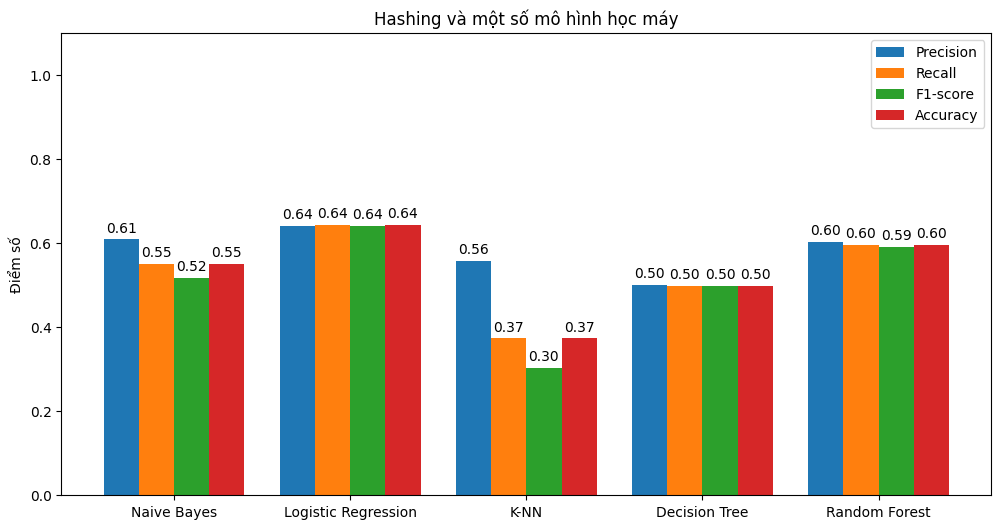

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score

# Tính báo cáo phân loại và lưu dưới dạng dictionary
nb_report = classification_report(y_test, y_pred_nb, output_dict=True)
lr_report = classification_report(y_test, y_pred_lr, output_dict=True)
knn_report = classification_report(y_test, y_pred_knn, output_dict=True)
dt_report = classification_report(y_test, y_pred_dt, output_dict=True)
rf_report = classification_report(y_test, y_pred_rf, output_dict=True)

# Tính accuracy cho từng mô hình
nb_accuracy = accuracy_score(y_test, y_pred_nb)
lr_accuracy = accuracy_score(y_test, y_pred_lr)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
dt_accuracy = accuracy_score(y_test, y_pred_dt)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

# Danh sách tên các phương pháp học máy
methods = ['Naive Bayes', 'Logistic Regression', "K-NN", 'Decision Tree', "Random Forest"]

# Lấy các chỉ số từ báo cáo phân loại dựa trên weighted avg
precision = [
    nb_report['weighted avg']['precision'],
    lr_report['weighted avg']['precision'],
    knn_report['weighted avg']['precision'],
    dt_report['weighted avg']['precision'],
    rf_report['weighted avg']['precision']
]
recall = [
    nb_report['weighted avg']['recall'],
    lr_report['weighted avg']['recall'],
    knn_report['weighted avg']['recall'],
    dt_report['weighted avg']['recall'],
    rf_report['weighted avg']['recall']
]
f1 = [
    nb_report['weighted avg']['f1-score'],
    lr_report['weighted avg']['f1-score'],
    knn_report['weighted avg']['f1-score'],
    dt_report['weighted avg']['f1-score'],
    rf_report['weighted avg']['f1-score']
]
accuracy = [nb_accuracy, lr_accuracy, knn_accuracy, dt_accuracy, rf_accuracy]

# Chuẩn bị vẽ biểu đồ: trục x là các phương pháp học máy
x = np.arange(len(methods))
width = 0.2  # Độ rộng của mỗi cột
# Các vị trí offset để căn chỉnh 4 cột đối xứng quanh mỗi nhóm
offsets = [-1.5 * width, -0.5 * width, 0.5 * width, 1.5 * width]

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x + offsets[0], precision, width, label='Precision')
rects2 = ax.bar(x + offsets[1], recall, width, label='Recall')
rects3 = ax.bar(x + offsets[2], f1, width, label='F1-score')
rects4 = ax.bar(x + offsets[3], accuracy, width, label='Accuracy')

# Hàm gắn số liệu (với định dạng 2 chữ số thập phân) lên trên mỗi cột
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3),  # cách trên 3 điểm
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1, ax)
autolabel(rects2, ax)
autolabel(rects3, ax)
autolabel(rects4, ax)

# Thiết lập nhãn, tiêu đề, trục x và legend
ax.set_ylabel('Điểm số')
ax.set_title('Hashing và một số mô hình học máy')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()

ax.set_ylim(0, 1.1)  # Giới hạn trục y từ 0 đến 1.05 để có khoảng trống cho số liệu

plt.show()

**Confusion Matrix**

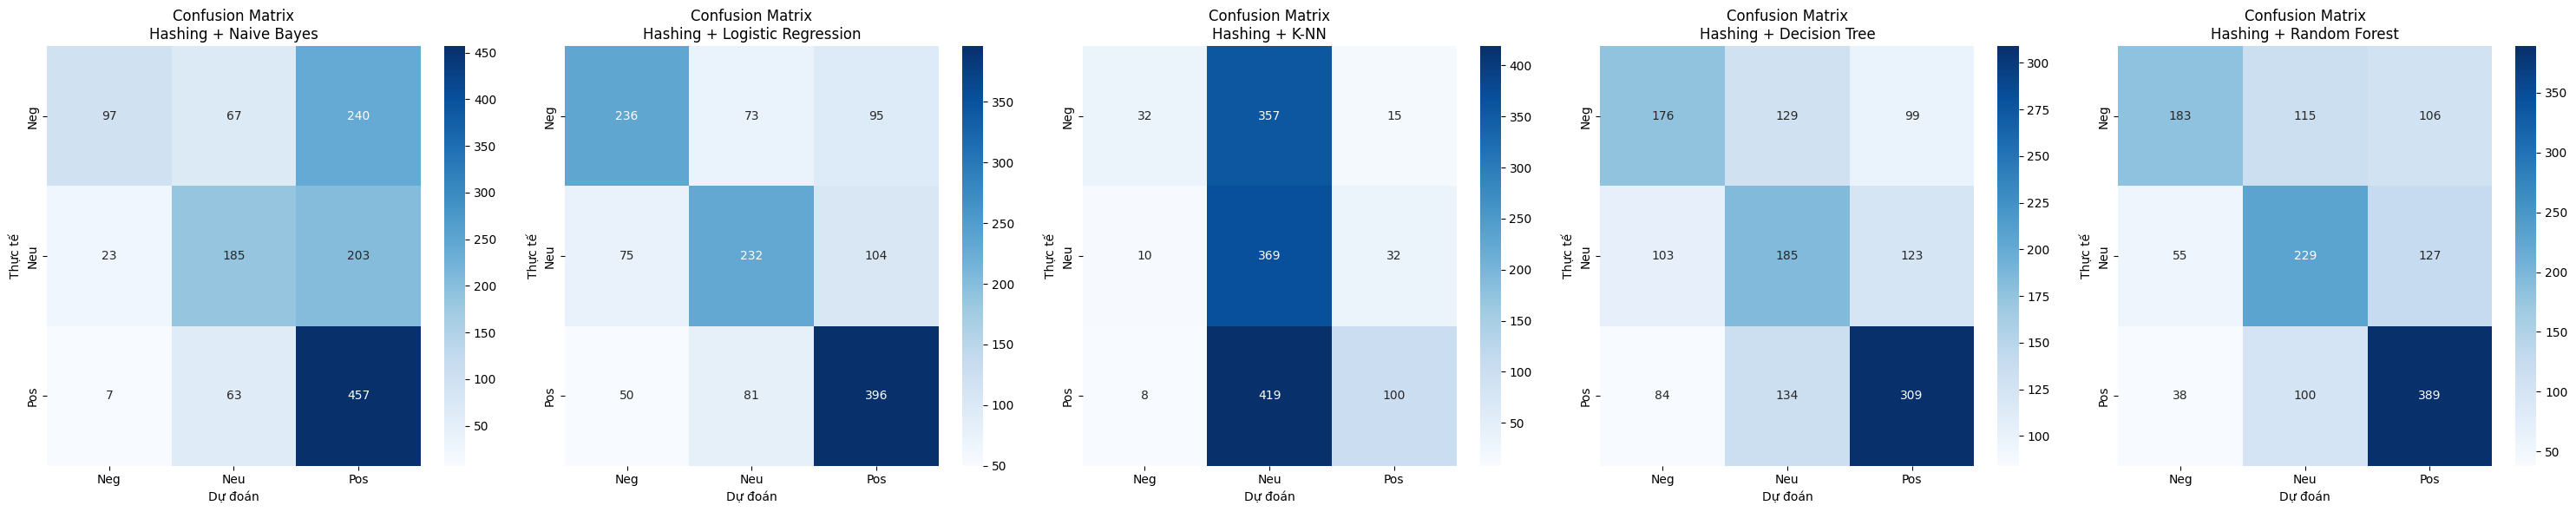

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Tạo figure với 5 subplots trên một hàng
fig, axs = plt.subplots(1, 5, figsize=(30, 6))

# --------------------
# Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues",
            xticklabels=nb_model.classes_,
            yticklabels=nb_model.classes_,
            ax=axs[0])
axs[0].set_xlabel("Dự đoán")
axs[0].set_ylabel("Thực tế")
axs[0].set_title("Confusion Matrix\nHashing + Naive Bayes")

# --------------------
# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=lr_model.classes_,
            yticklabels=lr_model.classes_,
            ax=axs[1])
axs[1].set_xlabel("Dự đoán")
axs[1].set_ylabel("Thực tế")
axs[1].set_title("Confusion Matrix\nHashing + Logistic Regression")

# --------------------
# K-NN
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues",
            xticklabels=knn_model.classes_,
            yticklabels=knn_model.classes_,
            ax=axs[2])
axs[2].set_xlabel("Dự đoán")
axs[2].set_ylabel("Thực tế")
axs[2].set_title("Confusion Matrix\nHashing + K-NN")

# --------------------
# Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues",
            xticklabels=dt_model.classes_,
            yticklabels=dt_model.classes_,
            ax=axs[3])
axs[3].set_xlabel("Dự đoán")
axs[3].set_ylabel("Thực tế")
axs[3].set_title("Confusion Matrix\nHashing + Decision Tree")

# --------------------
# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_,
            ax=axs[4])
axs[4].set_xlabel("Dự đoán")
axs[4].set_ylabel("Thực tế")
axs[4].set_title("Confusion Matrix\nHashing + Random Forest")

plt.tight_layout()
plt.show()


**Test**

In [ ]:
print("Hashing")

# Danh sách các comment cần dự đoán
comments = [
    "Bày này bánh cuốn quá",
    "2025 Ai còn xem không",
    "Thấy cũng ok mà nhiều người chê vậy",
    "Tệ vậy mà cũng có nghe khen? chán thật",
    "Why this song become popular? it's trash at all!!"
]

# Duyệt qua từng comment
for comment in comments:
    # Tiền xử lý văn bản
    comment_clean = process_text_str(comment)
    print("\nComment gốc:", comment)
    print("Comment sau khi tiền xử lý:", comment_clean)

    # Chuyển đổi comment sang vector
    X_new = vectorizer_hash.transform([comment_clean])

    # -----------------------
    # Dự đoán với mô hình Naive Bayes
    probs_nb = nb_model.predict_proba(X_new)[0]
    print("Dự đoán cảm xúc (Naive Bayes):")
    for sentiment, prob in zip(nb_model.classes_, probs_nb):
        print(f"  {sentiment}: {prob*100:.2f}%")

    # -----------------------
    # Dự đoán với mô hình Logistic Regression
    probs_lr = lr_model.predict_proba(X_new)[0]
    print("Dự đoán cảm xúc (Logistic Regression):")
    for sentiment, prob in zip(lr_model.classes_, probs_lr):
        print(f"  {sentiment}: {prob*100:.2f}%")

    # -----------------------
    # Dự đoán với mô hình K-Nearest Neighbors (K-NN)
    probs_knn = knn_model.predict_proba(X_new)[0]
    print("Dự đoán cảm xúc K-Nearest Neighbors (K-NN):")
    for sentiment, prob in zip(knn_model.classes_, probs_knn):
        print(f"  {sentiment}: {prob*100:.2f}%")

    # -----------------------
    # Dự đoán với mô hình Decision Tree
    probs_dt = dt_model.predict_proba(X_new)[0]
    print("Dự đoán cảm xúc (Decision Tree):")
    for sentiment, prob in zip(dt_model.classes_, probs_dt):
        print(f"  {sentiment}: {prob*100:.2f}%")

    # -----------------------
    # Dự đoán với mô hình Random Forest
    probs_rf = rf_model.predict_proba(X_new)[0]
    print("Dự đoán cảm xúc (Random Forest):")
    for sentiment, prob in zip(rf_model.classes_, probs_rf):
        print(f"  {sentiment}: {prob*100:.2f}%")
    print("===========================================================")


Hashing

Comment gốc: Bày này bánh cuốn quá
Comment sau khi tiền xử lý: bày này bánh cuốn quá
Dự đoán cảm xúc (Naive Bayes):
  Neg: 10.68%
  Neu: 6.12%
  Pos: 83.20%
Dự đoán cảm xúc (Logistic Regression):
  Neg: 9.48%
  Neu: 7.19%
  Pos: 83.32%
Dự đoán cảm xúc K-Nearest Neighbors (K-NN):
  Neg: 20.00%
  Neu: 60.00%
  Pos: 20.00%
Dự đoán cảm xúc (Decision Tree):
  Neg: 0.00%
  Neu: 0.00%
  Pos: 100.00%
Dự đoán cảm xúc (Random Forest):
  Neg: 13.00%
  Neu: 4.00%
  Pos: 83.00%

Comment gốc: 2025 Ai còn xem không
Comment sau khi tiền xử lý: ai còn xem không
Dự đoán cảm xúc (Naive Bayes):
  Neg: 8.52%
  Neu: 15.25%
  Pos: 76.23%
Dự đoán cảm xúc (Logistic Regression):
  Neg: 6.93%
  Neu: 19.10%
  Pos: 73.97%
Dự đoán cảm xúc K-Nearest Neighbors (K-NN):
  Neg: 0.00%
  Neu: 0.00%
  Pos: 100.00%
Dự đoán cảm xúc (Decision Tree):
  Neg: 0.00%
  Neu: 0.00%
  Pos: 100.00%
Dự đoán cảm xúc (Random Forest):
  Neg: 0.00%
  Neu: 1.00%
  Pos: 99.00%

Comment gốc: Thấy cũng ok mà nhiều người chê vậy
Commen

# **TF-IDF**


- Đo lường tần suất xuất hiện của một từ trong một tài liệu.

  + TF: Tỷ lệ xuất hiện của từ trong câu truy vấn (hoặc tài liệu) so với tổng số từ. số lần xuất hiện của từ đó / tổng số từ truy vấn

  + IDF: Được tính dựa trên số tài liệu trong tập huấn luyện mà từ đó xuất hiện. Từ càng hiếm thì IDF càng cao. log(số tài liệu / số tài liệu xuất hiện từ đó)

- TD-IDF là tích của 2 giá trị trên. Kết quả càng cao, từ càng hiếm và ngược lại

**Training**

In [ ]:
vectorizer_tf = TfidfVectorizer()
X = vectorizer_tf.fit_transform(df['Comment_raw'])
y = df['Sentiment']

# Chia dữ liệu thành tập huấn luyện và tập kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------------
# Mô hình Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
print("Naive Bayes accuracy:", accuracy_score(y_test, y_pred_nb))
print("Classification Report (Naive Bayes):")
print(classification_report(y_test, y_pred_nb))
print("===========================================================")

# -----------------------------
# Mô hình Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
print("Logistic Regression accuracy:", accuracy_score(y_test, y_pred_lr))
print("Classification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr))
print("===========================================================")

# -----------------------------
# Mô hình K-Nearest Neighbors (K-NN)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
print("K-Nearest Neighbors accuracy:", accuracy_score(y_test, y_pred_knn))
print("Classification Report (K-NN):")
print(classification_report(y_test, y_pred_knn))
print("===========================================================")

# -----------------------------
# Mô hình Decision Tree
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree accuracy:", accuracy_score(y_test, y_pred_dt))
print("Classification Report (Decision Tree):")
print(classification_report(y_test, y_pred_dt))
print("===========================================================")

# -----------------------------
# Mô hình Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))
print("===========================================================")


Naive Bayes accuracy: 0.6073025335320418
Classification Report (Naive Bayes):
              precision    recall  f1-score   support

         Neg       0.78      0.36      0.50       404
         Neu       0.63      0.53      0.57       411
         Pos       0.56      0.86      0.68       527

    accuracy                           0.61      1342
   macro avg       0.65      0.58      0.58      1342
weighted avg       0.65      0.61      0.59      1342

Logistic Regression accuracy: 0.6892697466467959
Classification Report (Logistic Regression):
              precision    recall  f1-score   support

         Neg       0.70      0.63      0.66       404
         Neu       0.68      0.63      0.65       411
         Pos       0.69      0.78      0.73       527

    accuracy                           0.69      1342
   macro avg       0.69      0.68      0.68      1342
weighted avg       0.69      0.69      0.69      1342

K-Nearest Neighbors accuracy: 0.34575260804769004
Classification R

**Biểu đồ cột**

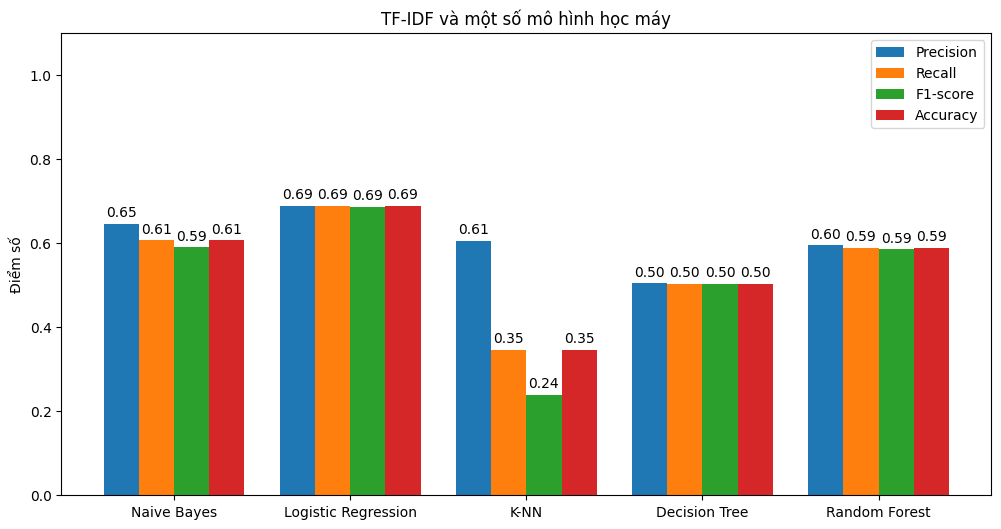

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score

# Tính báo cáo phân loại và lưu dưới dạng dictionary
nb_report = classification_report(y_test, y_pred_nb, output_dict=True)
lr_report = classification_report(y_test, y_pred_lr, output_dict=True)
knn_report = classification_report(y_test, y_pred_knn, output_dict=True)
dt_report = classification_report(y_test, y_pred_dt, output_dict=True)
rf_report = classification_report(y_test, y_pred_rf, output_dict=True)

# Tính accuracy cho từng mô hình
nb_accuracy = accuracy_score(y_test, y_pred_nb)
lr_accuracy = accuracy_score(y_test, y_pred_lr)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
dt_accuracy = accuracy_score(y_test, y_pred_dt)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

# Danh sách tên các phương pháp học máy
methods = ['Naive Bayes', 'Logistic Regression', "K-NN", 'Decision Tree', "Random Forest"]

# Lấy các chỉ số từ báo cáo phân loại dựa trên weighted avg
precision = [
    nb_report['weighted avg']['precision'],
    lr_report['weighted avg']['precision'],
    knn_report['weighted avg']['precision'],
    dt_report['weighted avg']['precision'],
    rf_report['weighted avg']['precision']
]
recall = [
    nb_report['weighted avg']['recall'],
    lr_report['weighted avg']['recall'],
    knn_report['weighted avg']['recall'],
    dt_report['weighted avg']['recall'],
    rf_report['weighted avg']['recall']
]
f1 = [
    nb_report['weighted avg']['f1-score'],
    lr_report['weighted avg']['f1-score'],
    knn_report['weighted avg']['f1-score'],
    dt_report['weighted avg']['f1-score'],
    rf_report['weighted avg']['f1-score']
]
accuracy = [nb_accuracy, lr_accuracy, knn_accuracy, dt_accuracy, rf_accuracy]

# Chuẩn bị vẽ biểu đồ: trục x là các phương pháp học máy
x = np.arange(len(methods))
width = 0.2  # Độ rộng của mỗi cột
# Các vị trí offset để căn chỉnh 4 cột đối xứng quanh mỗi nhóm
offsets = [-1.5 * width, -0.5 * width, 0.5 * width, 1.5 * width]

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x + offsets[0], precision, width, label='Precision')
rects2 = ax.bar(x + offsets[1], recall, width, label='Recall')
rects3 = ax.bar(x + offsets[2], f1, width, label='F1-score')
rects4 = ax.bar(x + offsets[3], accuracy, width, label='Accuracy')

# Hàm gắn số liệu (với định dạng 2 chữ số thập phân) lên trên mỗi cột
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3),  # cách trên 3 điểm
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1, ax)
autolabel(rects2, ax)
autolabel(rects3, ax)
autolabel(rects4, ax)

# Thiết lập nhãn, tiêu đề, trục x và legend
ax.set_ylabel('Điểm số')
ax.set_title('TF-IDF và một số mô hình học máy')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()

ax.set_ylim(0, 1.1)  # Giới hạn trục y từ 0 đến 1.05 để có khoảng trống cho số liệu

plt.show()

**Confusion Matrix**

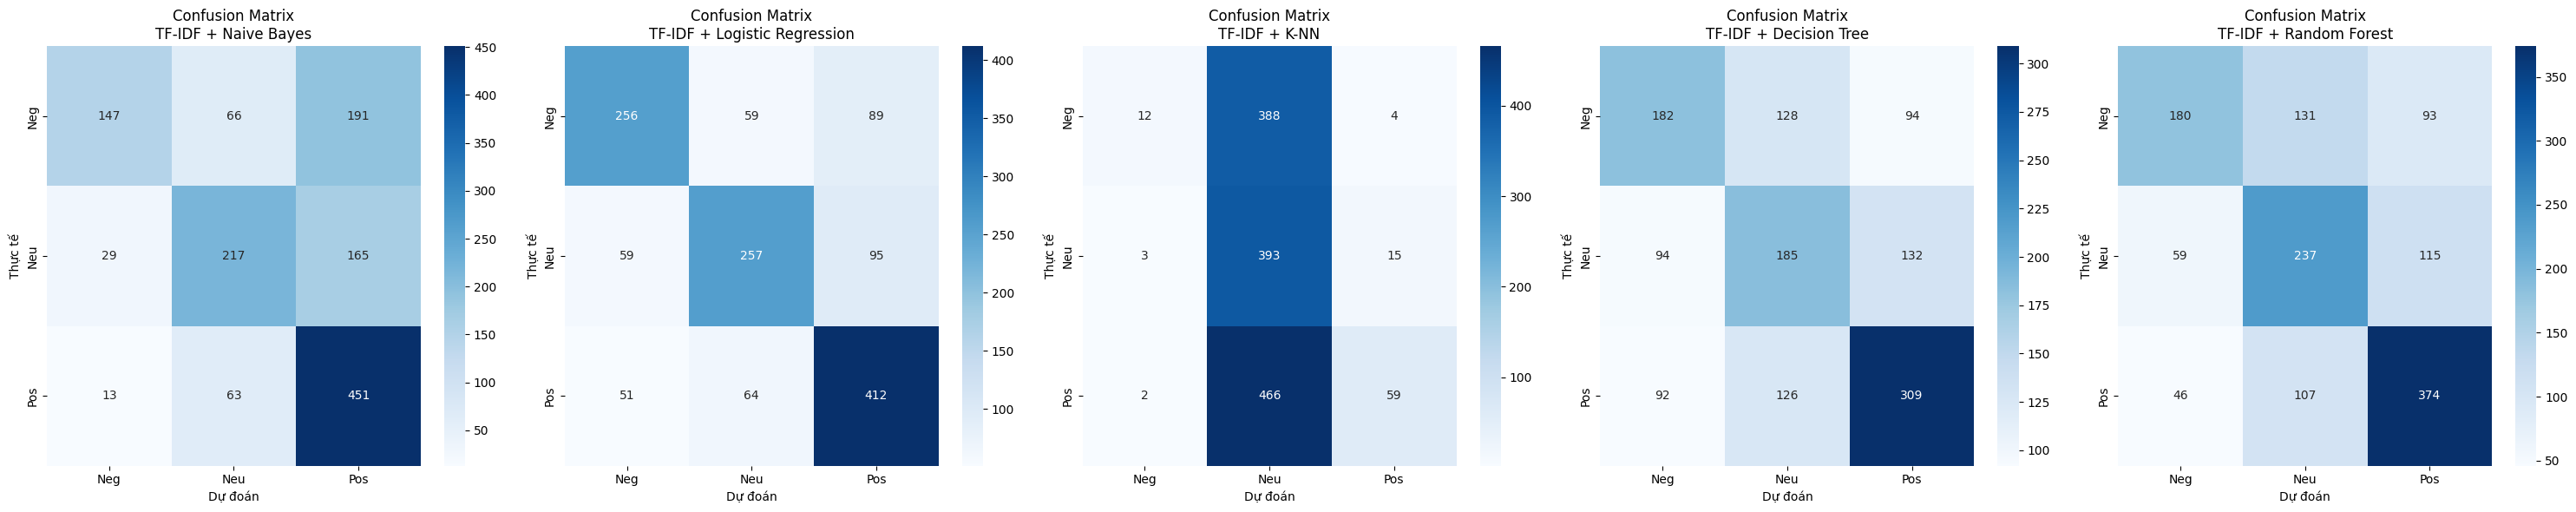

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Tạo figure với 5 subplots trên một hàng
fig, axs = plt.subplots(1, 5, figsize=(30, 6))

# --------------------
# Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues",
            xticklabels=nb_model.classes_,
            yticklabels=nb_model.classes_,
            ax=axs[0])
axs[0].set_xlabel("Dự đoán")
axs[0].set_ylabel("Thực tế")
axs[0].set_title("Confusion Matrix\nTF-IDF + Naive Bayes")

# --------------------
# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=lr_model.classes_,
            yticklabels=lr_model.classes_,
            ax=axs[1])
axs[1].set_xlabel("Dự đoán")
axs[1].set_ylabel("Thực tế")
axs[1].set_title("Confusion Matrix\nTF-IDF + Logistic Regression")

# --------------------
# K-NN
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues",
            xticklabels=knn_model.classes_,
            yticklabels=knn_model.classes_,
            ax=axs[2])
axs[2].set_xlabel("Dự đoán")
axs[2].set_ylabel("Thực tế")
axs[2].set_title("Confusion Matrix\nTF-IDF + K-NN")

# --------------------
# Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues",
            xticklabels=dt_model.classes_,
            yticklabels=dt_model.classes_,
            ax=axs[3])
axs[3].set_xlabel("Dự đoán")
axs[3].set_ylabel("Thực tế")
axs[3].set_title("Confusion Matrix\nTF-IDF + Decision Tree")

# --------------------
# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_,
            ax=axs[4])
axs[4].set_xlabel("Dự đoán")
axs[4].set_ylabel("Thực tế")
axs[4].set_title("Confusion Matrix\nTF-IDF + Random Forest")

plt.tight_layout()
plt.show()


**Test**

In [ ]:
print("TF-IDF")

# Danh sách các comment cần dự đoán
comments = [
    "Bày này bánh cuốn quá",
    "2025 Ai còn xem không",
    "Thấy cũng ok mà nhiều người chê vậy",
    "Tệ vậy mà cũng có nghe khen? chán thật",
]

# Duyệt qua từng comment
for comment in comments:
    # Tiền xử lý văn bản
    comment_clean = process_text_str(comment)
    print("\nComment gốc:", comment)
    print("Comment sau khi tiền xử lý:", comment_clean)

    # Chuyển đổi comment sang vector
    X_new = vectorizer_tf.transform([comment_clean])

    # -----------------------
    # Dự đoán với mô hình Naive Bayes
    probs_nb = nb_model.predict_proba(X_new)[0]
    print("Dự đoán cảm xúc (Naive Bayes):")
    for sentiment, prob in zip(nb_model.classes_, probs_nb):
        print(f"  {sentiment}: {prob*100:.2f}%")

    # -----------------------
    # Dự đoán với mô hình Logistic Regression
    probs_lr = lr_model.predict_proba(X_new)[0]
    print("Dự đoán cảm xúc (Logistic Regression):")
    for sentiment, prob in zip(lr_model.classes_, probs_lr):
        print(f"  {sentiment}: {prob*100:.2f}%")

    # -----------------------
    # Dự đoán với mô hình K-Nearest Neighbors (K-NN)
    probs_knn = knn_model.predict_proba(X_new)[0]
    print("Dự đoán cảm xúc K-Nearest Neighbors (K-NN):")
    for sentiment, prob in zip(knn_model.classes_, probs_knn):
        print(f"  {sentiment}: {prob*100:.2f}%")

    # -----------------------
    # Dự đoán với mô hình Decision Tree
    probs_dt = dt_model.predict_proba(X_new)[0]
    print("Dự đoán cảm xúc (Decision Tree):")
    for sentiment, prob in zip(dt_model.classes_, probs_dt):
        print(f"  {sentiment}: {prob*100:.2f}%")

    # -----------------------
    # Dự đoán với mô hình Random Forest
    probs_rf = rf_model.predict_proba(X_new)[0]
    print("Dự đoán cảm xúc (Random Forest):")
    for sentiment, prob in zip(rf_model.classes_, probs_rf):
        print(f"  {sentiment}: {prob*100:.2f}%")
    print("===========================================================")

TF-IDF

Comment gốc: Bày này bánh cuốn quá
Comment sau khi tiền xử lý: bày này bánh cuốn quá
Dự đoán cảm xúc (Naive Bayes):
  Neg: 13.98%
  Neu: 8.27%
  Pos: 77.75%
Dự đoán cảm xúc (Logistic Regression):
  Neg: 10.29%
  Neu: 7.33%
  Pos: 82.38%
Dự đoán cảm xúc K-Nearest Neighbors (K-NN):
  Neg: 0.00%
  Neu: 60.00%
  Pos: 40.00%
Dự đoán cảm xúc (Decision Tree):
  Neg: 0.00%
  Neu: 0.00%
  Pos: 100.00%
Dự đoán cảm xúc (Random Forest):
  Neg: 21.00%
  Neu: 2.00%
  Pos: 77.00%

Comment gốc: 2025 Ai còn xem không
Comment sau khi tiền xử lý: ai còn xem không
Dự đoán cảm xúc (Naive Bayes):
  Neg: 7.60%
  Neu: 15.09%
  Pos: 77.31%
Dự đoán cảm xúc (Logistic Regression):
  Neg: 5.98%
  Neu: 18.54%
  Pos: 75.48%
Dự đoán cảm xúc K-Nearest Neighbors (K-NN):
  Neg: 0.00%
  Neu: 20.00%
  Pos: 80.00%
Dự đoán cảm xúc (Decision Tree):
  Neg: 0.00%
  Neu: 0.00%
  Pos: 100.00%
Dự đoán cảm xúc (Random Forest):
  Neg: 0.00%
  Neu: 2.00%
  Pos: 98.00%

Comment gốc: Thấy cũng ok mà nhiều người chê vậy
Comment